<!-- type: tutorial -->
# Forecast Prep Contract → Model Hand-Off (v0.3.4)

This walkthrough demonstrates the **v0.3.4 sprint**: deterministic forecastability triage
followed by a typed `ForecastPrepContract` that wires three downstream models.

| Section | What it shows |
|---|---|
| 1 | Generate synthetic AR(1) series |
| 2 | Forecastability triage + fingerprint |
| 3 | Build the ForecastPrepContract |
| 4 | Inspect the contract |
| 5 | Wire sklearn Ridge from the contract |
| 6 | Wire MLForecast LGBMRegressor from the contract |
| 7 | Wire Darts LightGBMModel from the contract |
| 8 | Comparison table on a 12-step hold-out |

> **Scope.** Triage and contract building use only the public `forecastability` facade.
> Framework wiring (sklearn, mlforecast, darts) is illustrative — the `forecastability`
> package does not depend on any of these frameworks.


In [1]:
import os
from pathlib import Path as _P
_repo_root = _P.cwd()
if not (_repo_root / "pyproject.toml").exists():
    _repo_root = _repo_root.parent
os.chdir(_repo_root)
del _P, _repo_root

%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from forecastability import (
    ForecastPrepContract,
    TriageRequest,
    build_forecast_prep_contract,
    generate_ar1,
    run_forecastability_fingerprint,
    run_triage,
)
from forecastability.triage import AnalysisGoal
from forecastability.services.ami_information_geometry_service import AmiInformationGeometryConfig

SEED = 42
N = 300       # total series length
HORIZON = 12  # 12-step hold-out
MAX_LAG = 20
N_SURROGATES = 99

OUTPUT_ROOT = Path("outputs/notebooks/walkthroughs/05_forecast_prep_to_models")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)


## 1. Generate synthetic AR(1) series

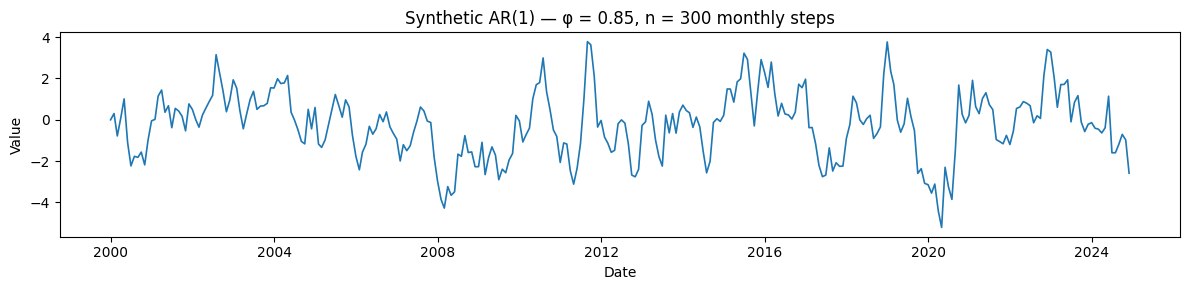

Series length: 300, range: [-5.21, 3.78]


In [2]:
series = generate_ar1(n_samples=N, phi=0.85, random_state=SEED)

months = pd.date_range("2000-01", periods=N, freq="MS")

plt.figure(figsize=(12, 3))
plt.plot(months, series, linewidth=1.2)
plt.title("Synthetic AR(1) — φ = 0.85, n = 300 monthly steps")
plt.xlabel("Date")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

print(f"Series length: {len(series)}, range: [{series.min():.2f}, {series.max():.2f}]")


## 2. Forecastability triage + fingerprint

In [3]:
triage_result = run_triage(
    TriageRequest(
        series=series,
        goal=AnalysisGoal.univariate,
        max_lag=MAX_LAG,
        n_surrogates=N_SURROGATES,
        random_state=SEED,
    )
)

fp_bundle = run_forecastability_fingerprint(
    series,
    target_name="synthetic_ar1",
    max_lag=MAX_LAG,
    n_surrogates=N_SURROGATES,
    random_state=SEED,
    geometry_config=AmiInformationGeometryConfig(n_jobs=-1),
)

print("Triage result:")
print(f"  blocked:            {triage_result.blocked}")
print(f"  readiness status:   {triage_result.readiness.status.value}")
if triage_result.interpretation:
    print(f"  forecastability:    {triage_result.interpretation.forecastability_class}")
    print(f"  primary_lags:       {list(triage_result.interpretation.primary_lags)}")
print()
print("Fingerprint:")
print(f"  information_mass:   {fp_bundle.fingerprint.information_mass:.4f}")
print(f"  information_horizon:{fp_bundle.fingerprint.information_horizon}")
print(f"  signal_to_noise:    {fp_bundle.fingerprint.signal_to_noise:.4f}")
print(f"  recommended_primary:{fp_bundle.recommendation.primary_families}")


Triage result:
  blocked:            False
  readiness status:   clear
  forecastability:    high
  primary_lags:       [1]

Fingerprint:
  information_mass:   0.0471
  information_horizon:3
  signal_to_noise:    0.7171
  recommended_primary:['arima', 'ets', 'linear_state_space']


## 3. Build the ForecastPrepContract

In [4]:
contract = build_forecast_prep_contract(
    triage_result,
    horizon=HORIZON,
    target_frequency="MS",
    fingerprint_bundle=fp_bundle,
    add_calendar_features=False,
)

print(f"Contract version:         {contract.contract_version}")
print(f"Source goal:              {contract.source_goal}")
print(f"Blocked:                  {contract.blocked}")
print(f"Forecastability class:    {contract.forecastability_class}")
print(f"Confidence label:         {contract.confidence_label}")
print(f"Target frequency:         {contract.target_frequency}")
print(f"Horizon:                  {contract.horizon}")


Contract version:         0.3.4
Source goal:              univariate
Blocked:                  False
Forecastability class:    high
Confidence label:         medium
Target frequency:         MS
Horizon:                  12


## 4. Inspect the contract

In [5]:
contract_summary = {
    "recommended_target_lags": contract.recommended_target_lags,
    "recommended_seasonal_lags": contract.recommended_seasonal_lags,
    "candidate_seasonal_periods": contract.candidate_seasonal_periods,
    "recommended_families": contract.recommended_families,
    "baseline_families": contract.baseline_families,
    "transformation_hints": contract.transformation_hints,
    "caution_flags": contract.caution_flags,
    "past_covariates": contract.past_covariates,
    "future_covariates": contract.future_covariates,
}

rows = [(k, str(v)) for k, v in contract_summary.items()]
display(
    Markdown(
        "| Field | Value |\n|---|---|\n"
        + "\n".join(f"| `{k}` | `{v}` |" for k, v in rows)
    )
)


| Field | Value |
|---|---|
| `recommended_target_lags` | `[1]` |
| `recommended_seasonal_lags` | `[]` |
| `candidate_seasonal_periods` | `[]` |
| `recommended_families` | `['arima', 'ets', 'linear_state_space']` |
| `baseline_families` | `['naive', 'seasonal_naive']` |
| `transformation_hints` | `[]` |
| `caution_flags` | `['short_information_horizon']` |
| `past_covariates` | `[]` |
| `future_covariates` | `[]` |

## 5. Wire sklearn Ridge from the contract

In [6]:
from sklearn.linear_model import Ridge

# --- Use lags from the contract ---
target_lags = sorted(
    set(contract.recommended_target_lags + contract.recommended_seasonal_lags)
) or [1, 2, 3]
max_lag = max(target_lags)

train = series[: N - HORIZON]
test = series[N - HORIZON :]


def build_lag_matrix(
    arr: np.ndarray, lags: list[int]
) -> tuple[np.ndarray, np.ndarray]:
    max_l = max(lags)
    X, y = [], []
    for i in range(max_l, len(arr)):
        X.append([arr[i - lag] for lag in lags])
        y.append(arr[i])
    return np.array(X), np.array(y)


X_train, y_train = build_lag_matrix(train, target_lags)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# Autoregressive 12-step forecast
history = list(train)
ridge_preds: list[float] = []
for _ in range(HORIZON):
    feat = np.array([[history[-(lag)] for lag in target_lags]])
    p = float(ridge.predict(feat)[0])
    ridge_preds.append(p)
    history.append(p)

print(f"Ridge trained on {len(X_train)} lag-feature rows using lags {target_lags}")
print(f"Ridge predictions (first 6): {[f'{v:.3f}' for v in ridge_preds[:6]]}")


Ridge trained on 287 lag-feature rows using lags [1]
Ridge predictions (first 6): ['-0.218', '-0.217', '-0.217', '-0.216', '-0.216', '-0.215']


## 6. Wire MLForecast LGBMRegressor from the contract

In [7]:
import lightgbm as lgb
from mlforecast import MLForecast

train_df = pd.DataFrame({
    "unique_id": "series_1",
    "ds": pd.date_range("2000-01", periods=len(train), freq="MS"),
    "y": train,
})

mlf = MLForecast(
    models=[lgb.LGBMRegressor(n_estimators=50, random_state=SEED, verbose=-1)],
    freq="MS",
    lags=target_lags or [1],
)
mlf.fit(train_df, id_col="unique_id", time_col="ds", target_col="y")
mlf_result = mlf.predict(HORIZON)
mlf_preds = mlf_result.sort_values("ds")["LGBMRegressor"].to_numpy()

print(f"MLForecast trained with lags {target_lags}")
print(f"MLForecast predictions (first 6): {[f'{v:.3f}' for v in mlf_preds[:6]]}")


MLForecast trained with lags [1]
MLForecast predictions (first 6): ['0.292', '0.046', '0.444', '0.135', '0.254', '0.190']


## 7. Wire Darts LightGBMModel from the contract

In [8]:
from darts import TimeSeries
from darts.models import LightGBMModel

train_ts = TimeSeries.from_values(train)

# Darts uses negative integers for lags: lag 1 → -1, lag 2 → -2, etc.
darts_lags = [-lag for lag in target_lags]

darts_model = LightGBMModel(
    lags=darts_lags,
    output_chunk_length=HORIZON,
    n_estimators=50,
    random_state=SEED,
    verbose=-1,
)
darts_model.fit(train_ts)
darts_preds = darts_model.predict(HORIZON).values().flatten()

print(f"Darts LightGBMModel trained with lags {darts_lags} (contract lags {target_lags} negated)")
print(f"Darts predictions (first 6): {[f'{v:.3f}' for v in darts_preds[:6]]}")


Darts LightGBMModel trained with lags [-1] (contract lags [1] negated)
Darts predictions (first 6): ['0.129', '0.044', '-0.402', '-0.801', '-0.407', '-0.326']


## 8. Comparison table on a 12-step hold-out

### Hold-out comparison (12 steps)


'| Model                    |   sMAPE (%) |    MAE | Lags used   | Source               |\n|:-------------------------|------------:|-------:|:------------|:---------------------|\n| sklearn Ridge            |      115.04 | 0.8156 | [1]         | ForecastPrepContract |\n| MLForecast LGBMRegressor |      195.26 | 1.1738 | [1]         | ForecastPrepContract |\n| Darts LightGBMModel      |      107.9  | 0.7239 | [1]         | ForecastPrepContract |'

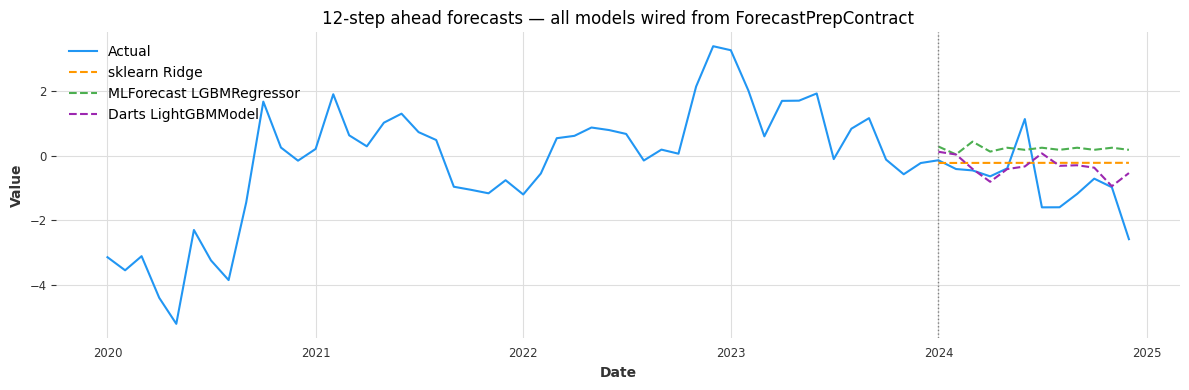

Comparison table saved to outputs/notebooks/walkthroughs/05_forecast_prep_to_models/comparison_table.csv


In [9]:
def smape(actual: np.ndarray, predicted: np.ndarray) -> float:
    denom = (np.abs(actual) + np.abs(predicted)) / 2
    denom = np.where(denom == 0, 1e-8, denom)
    return float(np.mean(np.abs(actual - predicted) / denom) * 100)


def mae(actual: np.ndarray, predicted: np.ndarray) -> float:
    return float(np.mean(np.abs(actual - predicted)))


results = {
    "sklearn Ridge": ridge_preds,
    "MLForecast LGBMRegressor": mlf_preds,
    "Darts LightGBMModel": darts_preds,
}

rows = []
for name, preds in results.items():
    preds_arr = np.array(preds)
    rows.append({
        "Model": name,
        "sMAPE (%)": f"{smape(test, preds_arr):.2f}",
        "MAE": f"{mae(test, preds_arr):.4f}",
        "Lags used": str(target_lags),
        "Source": "ForecastPrepContract",
    })

comparison_df = pd.DataFrame(rows)
display(Markdown("### Hold-out comparison (12 steps)\n"))
display(comparison_df.to_markdown(index=False))

# Plot
test_dates = pd.date_range(months[N - HORIZON], periods=HORIZON, freq="MS")
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(months[-60:], series[-60:], label="Actual", color="#2196F3", linewidth=1.5)
colors = ["#FF9800", "#4CAF50", "#9C27B0"]
for (name, preds), color in zip(results.items(), colors):
    ax.plot(test_dates, preds, label=name, color=color, linestyle="--", linewidth=1.5)
ax.axvline(test_dates[0], color="gray", linestyle=":", linewidth=1)
ax.set_title("12-step ahead forecasts — all models wired from ForecastPrepContract")
ax.set_xlabel("Date")
ax.set_ylabel("Value")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

# Save comparison table
out_csv = OUTPUT_ROOT / "comparison_table.csv"
comparison_df.to_csv(out_csv, index=False)
print(f"Comparison table saved to {out_csv}")


## Summary

The `ForecastPrepContract` provided a single source of truth for model configuration:

- **`recommended_target_lags`** drove the lag feature set for all three models.
- **`recommended_families`** (`arima`, `ets`, `linear_state_space` for this AR(1) series)
  signal which model families the toolkit recommends — the hand-off frameworks implement
  these families.
- The contract is framework-agnostic: the `forecastability` package does not import
  `darts`, `mlforecast`, or `sklearn`.

**Where to go next:**
- `docs/recipes/forecast_prep_to_external_frameworks.md` in the core repo for the illustrative text recipes.
- `walkthroughs/05_forecast_prep_to_models.ipynb` (this notebook) for the runnable demo.
- `ForecastPrepContract.model_dump_json()` for serialisation — see `recipes/contract_roundtrip.ipynb`.
